# 0.0 Set up

In [24]:
import re
import os, sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path 
import geopandas as gpd

# Change working directory to project directory
project_dir = str(Path.cwd().parent)
if 'modules' not in os.listdir(Path.cwd()):
    os.chdir(project_dir)

# 1.0 Map resources

## 1.1 PSGC shapefiles

In [7]:
from modules import psgc_consolidator

# Reload the module
importlib.reload(psgc_consolidator)

from modules import psgc_consolidator as pc

In [8]:
!ls data/philippines-psgc-shapefiles

LICENSE  README.md  data  dist	docs  pyproject.toml  renovate.json  src  tests


In [9]:
# Initialize consolidator
path = "data/philippines-psgc-shapefiles/dist"
consolidator = pc.PSGCConsolidator(base_path=path)

# Process data
geodata = consolidator.process()

# Get summary
summary = consolidator.get_summary()

INFO:modules.psgc_consolidator:Starting PSGC consolidation pipeline
INFO:modules.psgc_consolidator:Loading PSGC data from data/philippines-psgc-shapefiles/dist
INFO:modules.psgc_consolidator:Loading Adm1 (Regions) data...
INFO:modules.psgc_consolidator:Trimmed whitespaces from 2 string columns
INFO:modules.psgc_consolidator:Loaded 17 regions
INFO:modules.psgc_consolidator:Loading Adm2 (Provinces/Districts) data...
INFO:modules.psgc_consolidator:Trimmed whitespaces from 2 string columns
INFO:modules.psgc_consolidator:Loaded 88 provinces/districts
INFO:modules.psgc_consolidator:Loading Adm3 (Municipalities/Cities) data...
INFO:modules.psgc_consolidator:Trimmed whitespaces from 2 string columns
INFO:modules.psgc_consolidator:Loaded 1642 municipalities/cities
INFO:modules.psgc_consolidator:Loading Adm4 (Barangays/Sub-Municipalities) data...
INFO:modules.psgc_consolidator:Trimmed whitespaces from 2 string columns
INFO:modules.psgc_consolidator:Loaded 42017 barangays/sub-municipalities
INFO:

In [11]:
geodata.head()

,psgc_code,name,corr_code,geo_level_shp,city_class,inc_class,urb_rur,pop_2015,pop_2020,status,...,adm4_psgc,adm4_en_csv,geo_level_csv,len_crs,area_crs,len_km,area_km2,adm3_en,adm2_en,adm1_en
0,102801001,Adams,12801001.0,Bgy,None,None,None,R,None,None,...,102801001,Adams,Bgy,45997,111184551,45,111.0,Adams,Ilocos Norte,Region I (Ilocos Region)
1,102802001,Bani,12802001.0,Bgy,None,None,None,R,None,None,...,102802001,Bani,Bgy,5982,1761135,5,1.0,Bacarra,Ilocos Norte,Region I (Ilocos Region)
2,102802002,Buyon,12802002.0,Bgy,None,None,None,R,None,None,...,102802002,Buyon,Bgy,9117,3875134,9,3.0,Bacarra,Ilocos Norte,Region I (Ilocos Region)
3,102802003,Cabaruan,12802003.0,Bgy,None,None,None,R,None,None,...,102802003,Cabaruan,Bgy,7745,2987648,7,2.0,Bacarra,Ilocos Norte,Region I (Ilocos Region)
4,102802004,Cabulalaan,12802004.0,Bgy,None,None,None,R,None,None,...,102802004,Cabulalaan,Bgy,4502,1018354,4,1.0,Bacarra,Ilocos Norte,Region I (Ilocos Region)


In [16]:
shapes_adm4 = consolidator.adm4_geodata.copy()
print(shapes_adm4.shape)
display(shapes_adm4.head(3))

(45597, 20)


,psgc_code,name,corr_code,geo_level,city_class,inc_class,urb_rur,pop_2015,pop_2020,status,adm4_pcode,adm4_en,adm3_pcode,adm2_pcode,adm1_pcode,adm0_pcode,shape_len,shape_area,shape_sqkm,geometry
0,102801001,Adams,12801001.0,Bgy,None,None,None,R,None,None,PH0102801001,Adams (Pob.),PH0102801,PH01028,PH01,PH,0.423604,0.009506,111.143026,"POLYGON ((120.92068 18.51462, 120.94626 18.511..."
1,102802001,Bani,12802001.0,Bgy,None,None,None,R,None,None,PH0102802001,Bani,PH0102802,PH01028,PH01,PH,0.054894,0.000150,1.759757,"POLYGON ((120.61278 18.2759, 120.61282 18.2758..."
2,102802002,Buyon,12802002.0,Bgy,None,None,None,R,None,None,PH0102802002,Buyon,PH0102802,PH01028,PH01,PH,0.084185,0.000331,3.872158,"POLYGON ((120.62741 18.24638, 120.6337 18.2413..."


In [22]:
psgc_consolidated = consolidator.consolidated_data.copy()
print(psgc_consolidated.shape)
display(psgc_consolidated.head())

(42017, 13)


,adm1_psgc,adm2_psgc,adm3_psgc,adm4_psgc,adm4_en,geo_level,len_crs,area_crs,len_km,area_km2,adm3_en,adm2_en,adm1_en
0,100000000,102800000,102801000,102801001,Adams,Bgy,45997,111184551,45,111.0,Adams,Ilocos Norte,Region I (Ilocos Region)
1,100000000,102800000,102802000,102802001,Bani,Bgy,5982,1761135,5,1.0,Bacarra,Ilocos Norte,Region I (Ilocos Region)
2,100000000,102800000,102802000,102802002,Buyon,Bgy,9117,3875134,9,3.0,Bacarra,Ilocos Norte,Region I (Ilocos Region)
3,100000000,102800000,102802000,102802003,Cabaruan,Bgy,7745,2987648,7,2.0,Bacarra,Ilocos Norte,Region I (Ilocos Region)
4,100000000,102800000,102802000,102802004,Cabulalaan,Bgy,4502,1018354,4,1.0,Bacarra,Ilocos Norte,Region I (Ilocos Region)


In [49]:
psgc_ncr = psgc_consolidated[psgc_consolidated['adm1_en'].astype('string').str.contains(r'capital', flags=re.IGNORECASE)]
psgc_ncr_cities = psgc_ncr['adm3_en'].unique()
display(psgc_ncr_cities)

# City of Manila is the only missing city in the unique values of adm3_en
mask = (
    (psgc_ncr['adm3_en'].isna())
    & (psgc_ncr['adm2_en'].isna())
)
psgc_ncr_manila = psgc_ncr.loc[mask].copy()
print(psgc_ncr_manila.shape)
display(psgc_ncr_manila.head())

array([nan, 'City of Caloocan', 'City of Las Piñas', 'City of Makati',
       'City of Malabon', 'City of Mandaluyong', 'City of Marikina',
       'City of Muntinlupa', 'City of Navotas', 'City of Parañaque',
       'Pasay City', 'City of Pasig', 'Quezon City', 'City of San Juan',
       'City of Taguig', 'City of Valenzuela', 'Pateros'], dtype=object)

(897, 13)


,adm1_psgc,adm2_psgc,adm3_psgc,adm4_psgc,adm4_en,geo_level,len_crs,area_crs,len_km,area_km2,adm3_en,adm2_en,adm1_en
34032,1300000000,1380600000,1380601000,1380601001,Barangay 1,Bgy,1080,49547,1,0.0,NaN,NaN,National Capital Region (NCR)
34033,1300000000,1380600000,1380601000,1380601002,Barangay 2,Bgy,984,37885,0,0.0,NaN,NaN,National Capital Region (NCR)
34034,1300000000,1380600000,1380601000,1380601003,Barangay 3,Bgy,979,38940,0,0.0,NaN,NaN,National Capital Region (NCR)
34035,1300000000,1380600000,1380601000,1380601004,Barangay 4,Bgy,1095,40193,1,0.0,NaN,NaN,National Capital Region (NCR)
34036,1300000000,1380600000,1380601000,1380601005,Barangay 5,Bgy,679,24741,0,0.0,NaN,NaN,National Capital Region (NCR)


### 1.1.1 Plotting helpers

In [21]:
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

def plot_philippines_shapefile(gdf, 
                              title="Philippines Map",
                              figsize=(12, 14),
                              color='lightblue',
                              edgecolor='black',
                              linewidth=0.5,
                              simplified=True,
                              simplify_tolerance=0.01,
                              use_bounds=True,
                              dpi=100):
    """
    Efficiently plot Philippines shapefile from GeoDataFrame
    
    Parameters:
    -----------
    gdf : GeoDataFrame
        GeoDataFrame containing Philippines geometry
    title : str
        Title for the plot
    figsize : tuple
        Figure size (width, height)
    color : str
        Fill color for polygons
    edgecolor : str
        Edge color for polygons
    linewidth : float
        Width of polygon edges
    simplified : bool
        Whether to simplify geometry for faster rendering
    simplify_tolerance : float
        Tolerance for simplification (higher = more simplified)
    use_bounds : bool
        Whether to set specific bounds for Philippines
    dpi : int
        DPI for the figure (lower = faster rendering)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    
    # Create figure with lower DPI for faster rendering
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    
    # Simplify geometry if requested (reduces computational load)
    if simplified:
        gdf_plot = gdf.copy()
        gdf_plot['geometry'] = gdf_plot['geometry'].simplify(
            tolerance=simplify_tolerance, 
            preserve_topology=True
        )
    else:
        gdf_plot = gdf
    
    # Plot with minimal styling for efficiency
    gdf_plot.plot(
        ax=ax,
        color=color,
        edgecolor=edgecolor,
        linewidth=linewidth,
        alpha=0.8
    )
    
    # Set bounds specifically for Philippines to avoid unnecessary rendering
    if use_bounds:
        # Philippines approximate bounds
        ax.set_xlim([116.5, 127.5])  # Longitude
        ax.set_ylim([4.5, 21.5])     # Latitude
    
    # Minimal styling for efficiency
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_ylabel('Latitude', fontsize=10)
    
    # Add simple grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Aspect ratio suitable for Philippines
    ax.set_aspect('equal')
    
    plt.tight_layout()
    
    return fig, ax


def plot_philippines_regions(gdf, 
                            region_column=None,
                            cmap='Set3',
                            show_labels=False,
                            label_column=None,
                            **kwargs):
    """
    Plot Philippines with regions in different colors
    
    Parameters:
    -----------
    gdf : GeoDataFrame
        GeoDataFrame containing Philippines geometry
    region_column : str
        Column name containing region information
    cmap : str
        Colormap for regions
    show_labels : bool
        Whether to show region labels
    label_column : str
        Column to use for labels (if different from region_column)
    **kwargs : additional arguments passed to plot_philippines_shapefile
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    
    # Set default figure size if not provided
    if 'figsize' not in kwargs:
        kwargs['figsize'] = (12, 14)
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=kwargs.get('figsize'), 
                          dpi=kwargs.get('dpi', 100))
    
    # Simplify if requested
    if kwargs.get('simplified', True):
        gdf_plot = gdf.copy()
        gdf_plot['geometry'] = gdf_plot['geometry'].simplify(
            tolerance=kwargs.get('simplify_tolerance', 0.01),
            preserve_topology=True
        )
    else:
        gdf_plot = gdf
    
    # Plot with regions
    if region_column and region_column in gdf_plot.columns:
        gdf_plot.plot(
            column=region_column,
            ax=ax,
            cmap=cmap,
            edgecolor=kwargs.get('edgecolor', 'black'),
            linewidth=kwargs.get('linewidth', 0.5),
            alpha=0.8,
            legend=True,
            legend_kwds={'loc': 'upper left', 'fontsize': 8}
        )
    else:
        gdf_plot.plot(
            ax=ax,
            color=kwargs.get('color', 'lightblue'),
            edgecolor=kwargs.get('edgecolor', 'black'),
            linewidth=kwargs.get('linewidth', 0.5),
            alpha=0.8
        )
    
    # Add labels if requested (can be computationally expensive for many features)
    if show_labels and label_column and label_column in gdf_plot.columns:
        # Use representative points for label placement
        gdf_plot['label_point'] = gdf_plot.geometry.representative_point()
        
        for idx, row in gdf_plot.iterrows():
            ax.annotate(
                text=row[label_column],
                xy=(row.label_point.x, row.label_point.y),
                horizontalalignment='center',
                fontsize=6,
                fontweight='light'
            )
    
    # Set bounds for Philippines
    if kwargs.get('use_bounds', True):
        ax.set_xlim([116.5, 127.5])
        ax.set_ylim([4.5, 21.5])
    
    # Styling
    ax.set_title(kwargs.get('title', 'Philippines Regions Map'), 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_ylabel('Latitude', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    
    return fig, ax


def plot_philippines_minimal(gdf):
    """
    Ultra-minimal plotting for maximum speed
    
    Parameters:
    -----------
    gdf : GeoDataFrame
        GeoDataFrame containing Philippines geometry
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    
    # Simplify geometry aggressively
    gdf_simplified = gdf.copy()
    gdf_simplified['geometry'] = gdf_simplified['geometry'].simplify(
        tolerance=0.05,  # Higher tolerance for more simplification
        preserve_topology=True
    )
    
    # Plot with minimal settings
    fig, ax = plt.subplots(figsize=(8, 10), dpi=72)  # Lower DPI
    
    gdf_simplified.plot(
        ax=ax,
        color='#E8E8E8',  # Light gray
        edgecolor='#333333',  # Dark gray
        linewidth=0.3
    )
    
    # Minimal decorations
    ax.set_xlim([116.5, 127.5])
    ax.set_ylim([4.5, 21.5])
    ax.set_aspect('equal')
    ax.axis('off')  # Turn off axis for cleanest look
    
    plt.tight_layout()
    
    return fig, ax


# Example usage
if __name__ == "__main__":
    # Example 1: Load shapefile and plot basic map
    # gdf = gpd.read_file("path/to/philippines.shp")
    # fig, ax = plot_philippines_shapefile(gdf)
    # plt.show()
    
    # Example 2: Plot with regions
    # fig, ax = plot_philippines_regions(
    #     gdf, 
    #     region_column='REGION',
    #     show_labels=True,
    #     label_column='NAME_1'
    # )
    # plt.show()
    
    # Example 3: Ultra-fast minimal plot
    # fig, ax = plot_philippines_minimal(gdf)
    # plt.show()
    
    # Example 4: Custom optimization settings
    # fig, ax = plot_philippines_shapefile(
    #     gdf,
    #     simplified=True,
    #     simplify_tolerance=0.02,  # More aggressive simplification
    #     dpi=72,  # Lower DPI for faster rendering
    #     linewidth=0.3  # Thinner lines for faster drawing
    # )
    # plt.show()
    
    pass

### 1.1.2 Plot

#### Entire PH

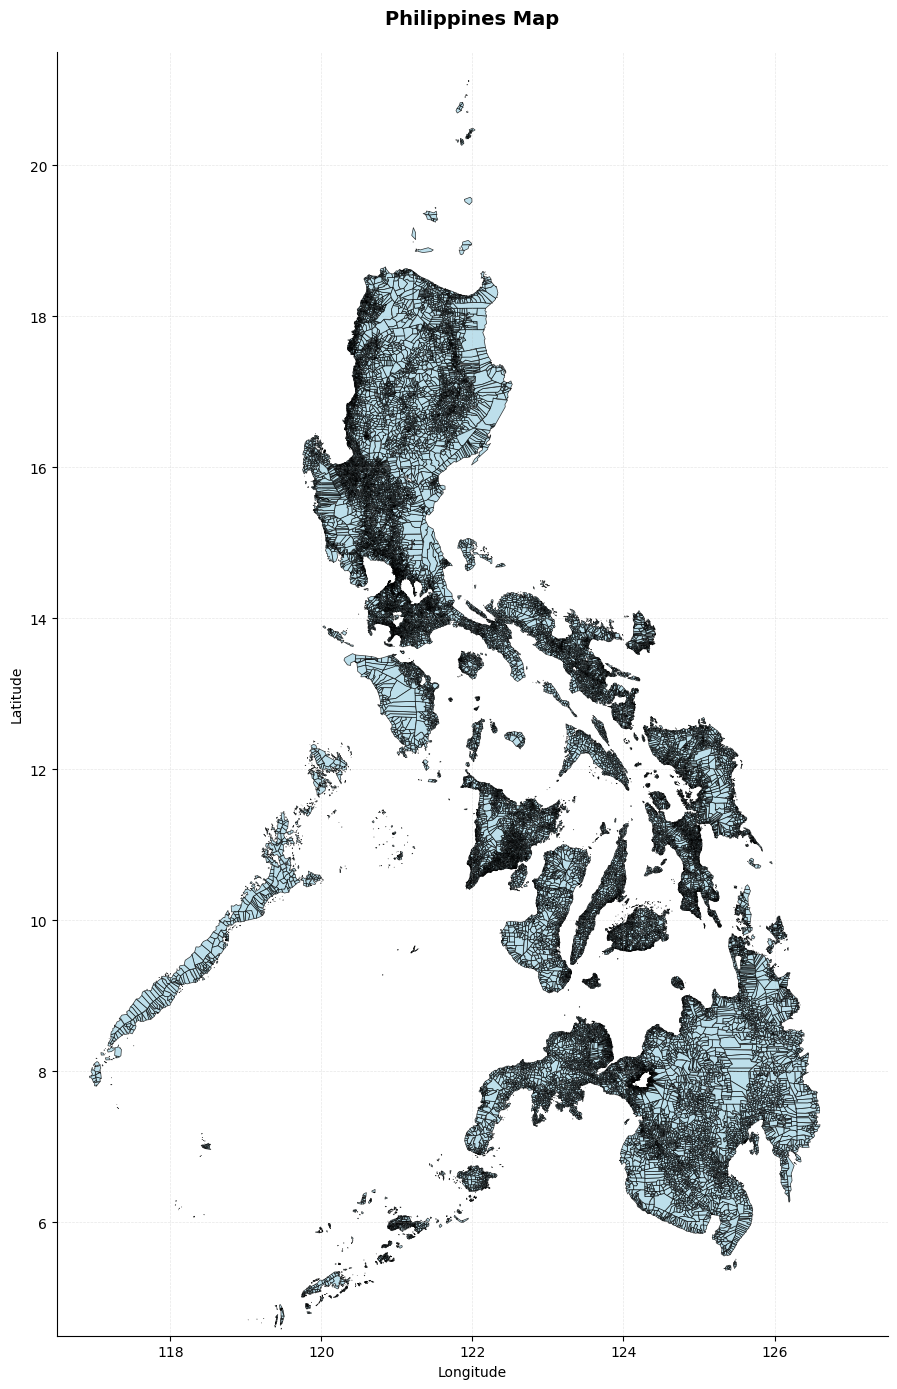

In [40]:
gdf = consolidator.adm4_geodata.copy()

# Example 1: Plot entire PH
fig, ax = plot_philippines_shapefile(gdf)
plt.show()

#### Inspect NCR

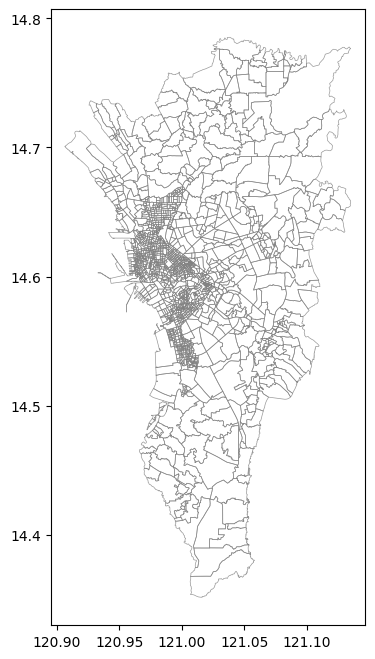

In [42]:
gdf = consolidator.adm4_geodata.copy()
gdf_ncr = gdf[gdf['adm1_pcode'] == 'PH13']

# Example 3: Ultra-fast minimal plot
fig, ax = plt.subplots(figsize=(8,8))

gdf_ncr.plot(
    ax=ax,
    color='none',
    edgecolor='grey',
    linewidth=.5,
    alpha=0.8
)

plt.show()

### 1.1.3 Preferred merge

In [72]:
tmp_psgc = consolidator.consolidated_data.copy()

# City of Manila is the only missing city in the unique values of adm3_en
mask = (
    (tmp_psgc['adm1_en'].astype('string').str.contains(r'capital', flags=re.IGNORECASE))
    & (tmp_psgc['adm3_en'].isna())
    & (tmp_psgc['adm2_en'].isna())
)
tmp_psgc.loc[mask, 'adm3_en'] = 'City of Manila'

# Rearrange columns
columns_psgc = [col for col in tmp_psgc.columns if '_psgc' in str(col)]
columns_en = [col for col in tmp_psgc.columns if '_en' in str(col)]
columns_other = [col for col in tmp_psgc.columns if col not in columns_psgc+columns_en]
tmp_psgc = tmp_psgc[columns_psgc+columns_en[::-1]+columns_other]

# Fix psgc codes whose leading 0s were omitted
def add_leading_zeros(psgc_code):
    code_str = str(psgc_code)
    if len(code_str) == 9:
        return '0'+code_str
    else:
        return code_str

for column in columns_psgc:
    tmp_psgc[column] = tmp_psgc[column].apply(add_leading_zeros)
    tmp_psgc[column] = tmp_psgc[column].astype('string')

print(tmp_psgc.shape)
display(tmp_psgc.head(3))

(42017, 13)


,adm1_psgc,adm2_psgc,adm3_psgc,adm4_psgc,adm1_en,adm2_en,adm3_en,adm4_en,geo_level,len_crs,area_crs,len_km,area_km2
0,0100000000,0102800000,0102801000,0102801001,Region I (Ilocos Region),Ilocos Norte,Adams,Adams,Bgy,45997,111184551,45,111.0
1,0100000000,0102800000,0102802000,0102802001,Region I (Ilocos Region),Ilocos Norte,Bacarra,Bani,Bgy,5982,1761135,5,1.0
2,0100000000,0102800000,0102802000,0102802002,Region I (Ilocos Region),Ilocos Norte,Bacarra,Buyon,Bgy,9117,3875134,9,3.0


In [102]:
# tmp_psgc.dtypes

In [101]:
tmp_psgc.isna().sum()

adm1_psgc       0
adm2_psgc       0
adm3_psgc       0
adm4_psgc       0
adm1_en        14
adm2_en      3097
adm3_en        16
adm4_en         2
geo_level       2
len_crs         0
area_crs        0
len_km          0
area_km2        0
dtype: int64

In [91]:
tmp_geodata = consolidator.adm4_geodata.copy()

# Add back leading zeros
tmp_geodata['psgc_code'] = tmp_geodata['psgc_code'].apply(add_leading_zeros)
tmp_geodata['psgc_code'] = tmp_geodata['psgc_code'].astype('string')

# Identify relevant columns to be included in merge
columns_relevant = ['psgc_code','name','adm4_en','geometry']
tmp_geodata = tmp_geodata[columns_relevant]

# Drop rows without geometry
mask = tmp_geodata['geometry'].isna()
tmp_geodata = tmp_geodata.loc[~mask]

print(tmp_geodata.shape)
tmp_geodata.head(3)

(42048, 4)


,psgc_code,name,adm4_en,geometry
0,0102801001,Adams,Adams (Pob.),"POLYGON ((120.92068 18.51462, 120.94626 18.511..."
1,0102802001,Bani,Bani,"POLYGON ((120.61278 18.2759, 120.61282 18.2758..."
2,0102802002,Buyon,Buyon,"POLYGON ((120.62741 18.24638, 120.6337 18.2413..."


In [100]:
tmp_geodata.isna().sum()

psgc_code       0
name         3582
adm4_en         0
geometry        0
dtype: int64

In [114]:
consolidated_geodata = tmp_geodata.merge(
    tmp_psgc,
    left_on='psgc_code', right_on='adm4_psgc',
    how='left',
    suffixes=('_psgc','_shapes')
)

# # Drop rows whose adm1_psgc is NaN
# mask = consolidated_geodata['adm1_psgc'].isna()
# consolidated_geodata = consolidated_geodata.loc[~mask]

# Transform to GeoDataFrame
consolidated_geodata = gpd.GeoDataFrame(consolidated_geodata, geometry='geometry', crs=4326)

print(consolidated_geodata.shape)

(42048, 17)


In [116]:
consolidated_geodata.head()

,psgc_code,name,adm4_en_psgc,geometry,adm1_psgc,adm2_psgc,adm3_psgc,adm4_psgc,adm1_en,adm2_en,adm3_en,adm4_en_shapes,geo_level,len_crs,area_crs,len_km,area_km2
0,0102801001,Adams,Adams (Pob.),"POLYGON ((120.92068 18.51462, 120.94626 18.511...",0100000000,0102800000,0102801000,0102801001,Region I (Ilocos Region),Ilocos Norte,Adams,Adams,Bgy,45997.0,111184551.0,45.0,111.0
1,0102802001,Bani,Bani,"POLYGON ((120.61278 18.2759, 120.61282 18.2758...",0100000000,0102800000,0102802000,0102802001,Region I (Ilocos Region),Ilocos Norte,Bacarra,Bani,Bgy,5982.0,1761135.0,5.0,1.0
2,0102802002,Buyon,Buyon,"POLYGON ((120.62741 18.24638, 120.6337 18.2413...",0100000000,0102800000,0102802000,0102802002,Region I (Ilocos Region),Ilocos Norte,Bacarra,Buyon,Bgy,9117.0,3875134.0,9.0,3.0
3,0102802003,Cabaruan,Cabaruan,"POLYGON ((120.58982 18.26839, 120.60407 18.259...",0100000000,0102800000,0102802000,0102802003,Region I (Ilocos Region),Ilocos Norte,Bacarra,Cabaruan,Bgy,7745.0,2987648.0,7.0,2.0
4,0102802004,Cabulalaan,Cabulalaan,"POLYGON ((120.58368 18.2821, 120.58401 18.2820...",0100000000,0102800000,0102802000,0102802004,Region I (Ilocos Region),Ilocos Norte,Bacarra,Cabulalaan,Bgy,4502.0,1018354.0,4.0,1.0


In [117]:
consolidated_geodata.isna().sum()

psgc_code            0
name              3582
adm4_en_psgc         0
geometry             0
adm1_psgc         3580
adm2_psgc         3580
adm3_psgc         3580
adm4_psgc         3580
adm1_en           3580
adm2_en           3580
adm3_en           3582
adm4_en_shapes    3582
geo_level         3582
len_crs           3580
area_crs          3580
len_km            3580
area_km2          3580
dtype: int64

In [120]:
consolidated_geodata[consolidated_geodata['adm4_en_shapes'].isna()]

,psgc_code,name,adm4_en_psgc,geometry,adm1_psgc,adm2_psgc,adm3_psgc,adm4_psgc,adm1_en,adm2_en,adm3_en,adm4_en_shapes,geo_level,len_crs,area_crs,len_km,area_km2
7236,0305401001,None,Agapito del Rosario,"POLYGON ((120.58988 15.14755, 120.59015 15.146...",<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7237,0305401002,None,Anunas,"POLYGON ((120.56012 15.16583, 120.56044 15.165...",<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7238,0305401003,None,Balibago,"POLYGON ((120.5709 15.22239, 120.57103 15.2224...",<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7239,0305401004,None,Capaya,"POLYGON ((120.63596 15.15064, 120.63655 15.150...",<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7240,0305401005,None,Claro M. Recto,"POLYGON ((120.59362 15.14862, 120.59376 15.148...",<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42043,1909908004,None,Lagunde,"POLYGON ((124.6232 7.07579, 124.62318 7.07054,...",<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42044,1909908005,None,Macasendeg,"POLYGON ((124.56663 7.05121, 124.56074 7.0323,...",<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42045,1909908006,None,Manaulanan,"POLYGON ((124.62026 7.05817, 124.6205 7.05709,...",<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42046,1909908007,None,Pamalian,"POLYGON ((124.61168 7.05983, 124.61191 7.04989...",<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


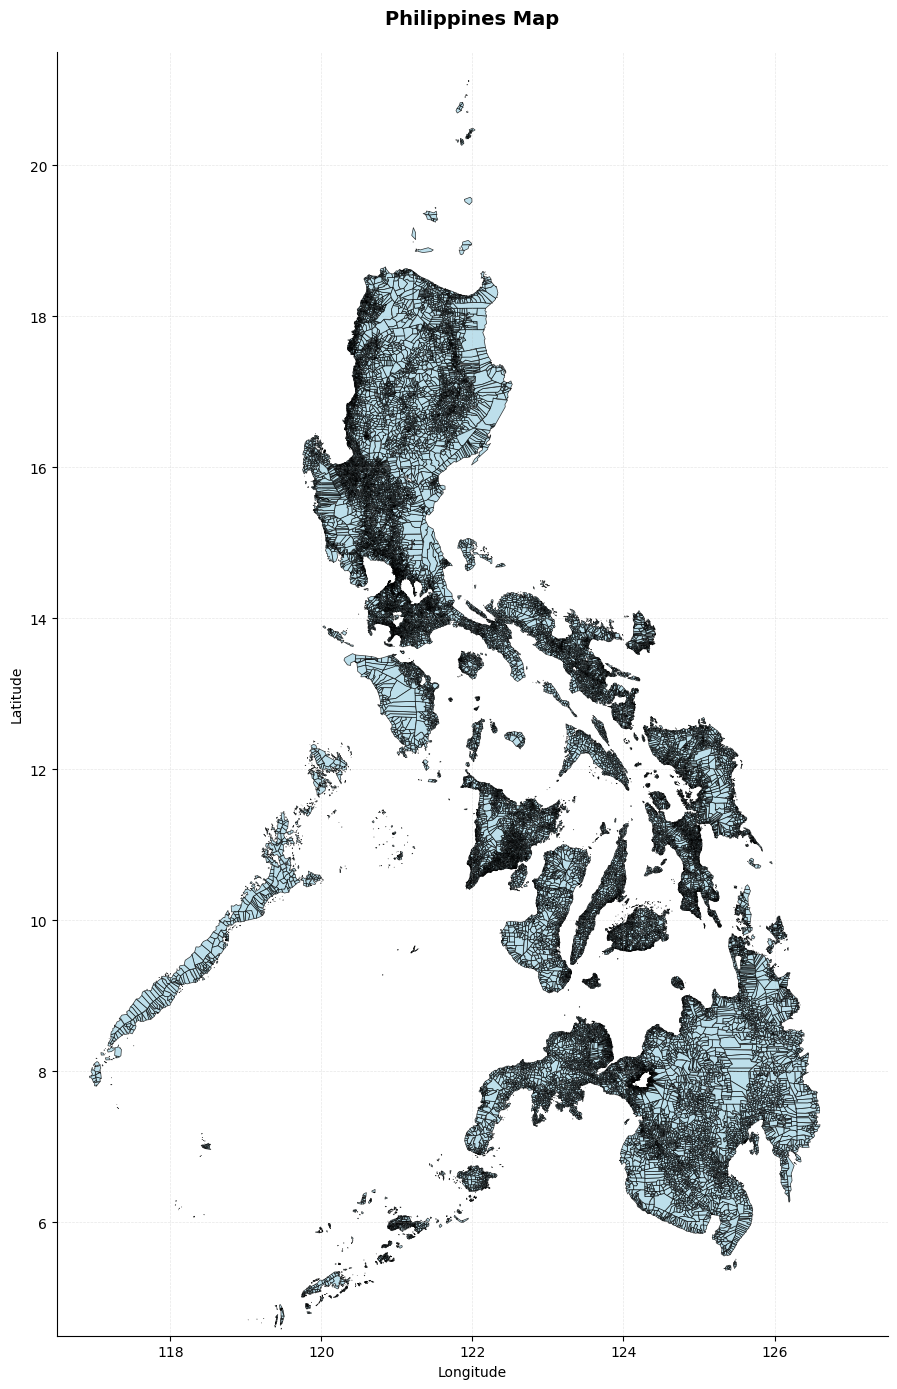

In [119]:
# gdf = consolidator.adm4_geodata.copy()

# Example 1: Plot entire PH
fig, ax = plot_philippines_shapefile(consolidated_geodata, figsize=(12,14))
plt.show()